In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], prefix=['op'])
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,op_<1H OCEAN,op_INLAND,op_ISLAND,op_NEAR BAY,op_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [9]:
print(df_encoded.isnull().sum())
df_encoded.dropna(subset=['total_bedrooms'], inplace=True)
print()
print(df_encoded.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
op_<1H OCEAN            0
op_INLAND               0
op_ISLAND               0
op_NEAR BAY             0
op_NEAR OCEAN           0
dtype: int64

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
op_<1H OCEAN          0
op_INLAND             0
op_ISLAND             0
op_NEAR BAY           0
op_NEAR OCEAN         0
dtype: int64


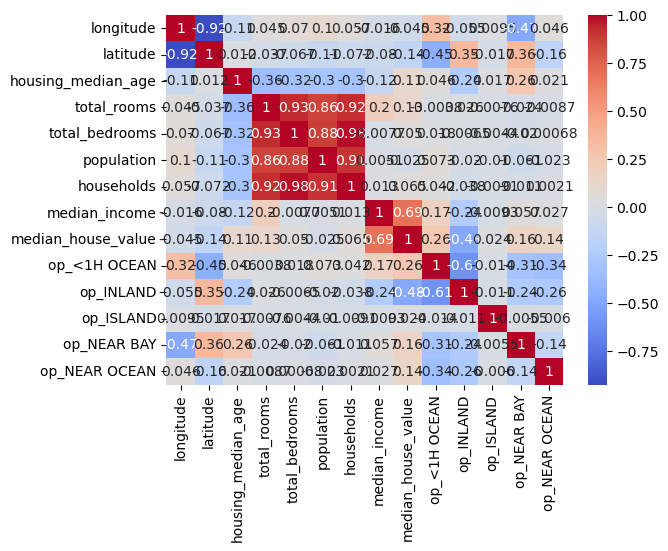

In [ ]:
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
display

In [16]:
y = df_encoded['median_house_value']
X = df_encoded[df_encoded.columns.drop('median_house_value')]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
mi = mutual_info_regression(X_train, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
display(mi_series.to_frame('mutual_information'))

,mutual_information
longitude,0.398749
median_income,0.386002
latitude,0.369833
op_INLAND,0.204837
op_<1H OCEAN,0.105057
housing_median_age,0.045083
total_rooms,0.035154
households,0.025816
total_bedrooms,0.024562
population,0.018269
